In [30]:
!pip install -q pandas scikit-learn matplotlib seaborn

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

## Part 1: Graduate School Admission (GRE, GPA, Prestige)

**Dataset:** [UCLA IDRE — binary.dta](https://stats.idre.ucla.edu/stat/stata/dae/binary.dta)

`admit` (0/1) is the response variable, predicted from `gre`, `gpa`, and `rank`
(prestige of the undergraduate institution, 1 = highest prestige, 4 = lowest).
`pandas.read_stata()` can load a `.dta` file directly from a URL — this cell needs
internet access (works out-of-the-box in Google Colab).


In [32]:
url = 'https://stats.idre.ucla.edu/stat/stata/dae/binary.dta'
data1 = pd.read_stata(url)
print(data1.shape)
data1.head()

(400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [33]:
data1.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [34]:
data1['rank'] = data1['rank'].astype('category')
data1 = pd.get_dummies(data1, columns=['rank'], drop_first=True)
data1.head()

,admit,gre,gpa,rank_2.0,rank_3.0,rank_4.0
0,0.0,380.0,3.61,False,True,False
1,1.0,660.0,3.67,False,True,False
2,1.0,800.0,4.00,False,False,False
3,1.0,640.0,3.19,False,False,True
4,0.0,520.0,2.93,False,False,True


In [35]:
x1 = data1.drop('admit', axis=1)
y1 = data1['admit']

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=5)
print(x1_train.shape, x1_test.shape)

(320, 5) (80, 5)


In [36]:
model1 = LogisticRegression(solver='lbfgs', max_iter=1000)
model1.fit(x1_train, y1_train)
y1_pred = model1.predict(x1_test)
print('y_pred:', y1_pred)

y_pred: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0.]


In [37]:
conf_mat1 = metrics.confusion_matrix(y1_test, y1_pred)
print('Confusion Matrix:\n', conf_mat1)

acc1 = metrics.accuracy_score(y1_test, y1_pred)
print('Accuracy Score:', acc1)
print('Accuracy in Percentage:', int(acc1*100), '%')
print('\n', metrics.classification_report(y1_test, y1_pred))

Confusion Matrix:
 [[49  5]
 [25  1]]
Accuracy Score: 0.625
Accuracy in Percentage: 62 %

               precision    recall  f1-score   support

         0.0       0.66      0.91      0.77        54
         1.0       0.17      0.04      0.06        26

    accuracy                           0.62        80
   macro avg       0.41      0.47      0.41        80
weighted avg       0.50      0.62      0.54        80



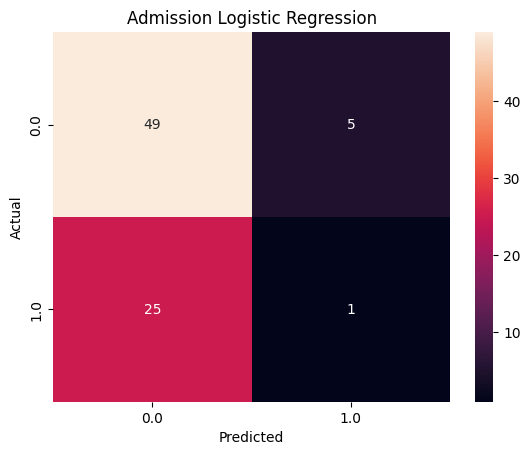

In [38]:
cm1 = pd.crosstab(y1_test, y1_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(cm1, annot=True, fmt='d').set(title='Admission Logistic Regression')
plt.show()

In [39]:
new_applicant = pd.DataFrame({'gre':[680], 'gpa':[3.5], 'rank_2':[1], 'rank_3':[0], 'rank_4':[0]})
new_applicant = new_applicant.reindex(columns=x1.columns, fill_value=0)
prob = model1.predict_proba(new_applicant)[:, 1]
print(f'Predicted probability of admission: {prob[0]*100:.2f}%')

Predicted probability of admission: 52.14%


---
## Part 2: Disease Susceptibility (Medical Example)

**Reference:** DataTab's [Logistic Regression Calculator — medical example](https://datatab.net/statistics-calculator/regression/logistic-regression-calculator?example=Medical_example_logistic_regression),
which illustrates predicting `disease` (0 = not diseased, 1 = diseased) from `Age`,
`Gender`, and `Smoker status`.

**Dataset used:** `numiqo1.xlsx` (the real DataTab medical-example sample table, 36
patients) with columns `Disease`, `Age`, `Gender`, `Smoker status`. Run the next cell
to upload `numiqo1.xlsx`, then the cell after it reads the data.

In [40]:
import os

if not os.path.exists('numiqo1.xlsx'):
    try:
        from google.colab import files
        print('Please select numiqo1.xlsx to upload:')
        uploaded = files.upload()
    except ImportError:
        print('Not running in Colab. Please upload numiqo1.xlsx using the Jupyter '
              'file-browser (or place it in this working directory), then re-run this cell.')
else:
    print('numiqo1.xlsx found in working directory.')

numiqo1.xlsx found in working directory.


In [41]:
data2 = pd.read_excel('numiqo1.xlsx', sheet_name='Data')
print(data2.shape)
data2.head()

(36, 4)


,Disease,Age,Gender,Smoker status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker


In [42]:
data2.isnull().sum()

,0
Disease,0
Age,0
Gender,0
Smoker status,0


In [43]:
data2['disease'] = data2['Disease'].map({'diseased': 1, 'not diseased': 0})
data2['gender'] = data2['Gender'].map({'Male': 1, 'Female': 0})
data2['smoker'] = data2['Smoker status'].map({'Smoker': 1, 'Non-smoker': 0})
data2['age'] = data2['Age']

data2[['age', 'gender', 'smoker', 'disease']].head()

,age,gender,smoker,disease
0,43,1,1,1
1,18,1,1,0
2,22,0,0,1
3,25,1,0,1
4,45,0,1,0


In [44]:
x2 = data2[['age', 'gender', 'smoker']]
y2 = data2['disease']

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=5)
print(x2_train.shape, x2_test.shape)

(28, 3) (8, 3)


In [45]:
model2 = LogisticRegression(solver='lbfgs', max_iter=1000)
model2.fit(x2_train, y2_train)
y2_pred = model2.predict(x2_test)
print('y_pred:', y2_pred)

y_pred: [1 0 0 1 1 0 1 1]


In [46]:
conf_mat2 = metrics.confusion_matrix(y2_test, y2_pred)
print('Confusion Matrix:\n', conf_mat2)

acc2 = metrics.accuracy_score(y2_test, y2_pred)
print('Accuracy Score:', acc2)
print('Accuracy in Percentage:', int(acc2*100), '%')
print('\n', metrics.classification_report(y2_test, y2_pred))

Confusion Matrix:
 [[2 0]
 [1 5]]
Accuracy Score: 0.875
Accuracy in Percentage: 87 %

               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.83      0.91         6

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8



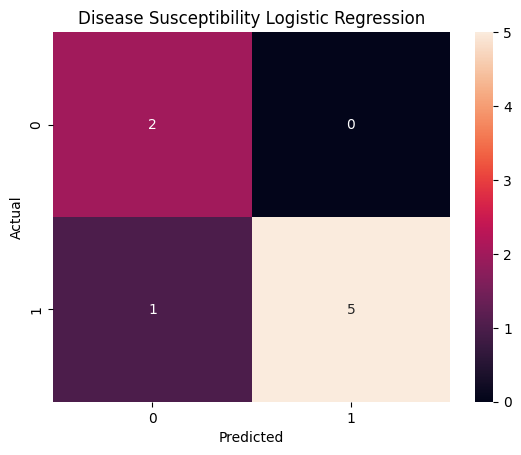

In [47]:
cm2 = pd.crosstab(y2_test, y2_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(cm2, annot=True, fmt='d').set(title='Disease Susceptibility Logistic Regression')
plt.show()

In [48]:
new_patient = pd.DataFrame({'age':[55], 'gender':[1], 'smoker':[1]})  # gender: 1=Male, 0=Female | smoker: 1=Smoker, 0=Non-smoker
prob2 = model2.predict_proba(new_patient)[:, 1]
print(f'Predicted probability of disease: {prob2[0]*100:.2f}%')

Predicted probability of disease: 72.47%


---
## Part 3: Online Retailer — Predict Product Purchase

**Reference:** DataTab's [Logistic Regression Calculator — retail example](https://datatab.net/statistics-calculator/regression/logistic-regression-calculator?example=logistic_regression),
which illustrates predicting a visitor's purchasing behaviour from features like
age, gender, and time spent in the online shop.

**Dataset used:** `numiqo2.xlsx` (the real DataTab retail-example sample table, 24
customers) with columns `Purchasing behaviour` (`Buy now` / `Buy later` /
`Don't buy anything`), `Gender`, `Age`, and `Time spent in online shop`. This is a
3-class target, so the logistic regression below is multiclass. Run the next cell
to upload `numiqo2.xlsx`, then the cell after it reads the data.

In [49]:
import os

if not os.path.exists('numiqo2.xlsx'):
    try:
        from google.colab import files
        print('Please select numiqo2.xlsx to upload:')
        uploaded = files.upload()
    except ImportError:
        print('Not running in Colab. Please upload numiqo2.xlsx using the Jupyter '
              'file-browser (or place it in this working directory), then re-run this cell.')
else:
    print('numiqo2.xlsx found in working directory.')

numiqo2.xlsx found in working directory.


In [50]:
data3 = pd.read_excel('numiqo2.xlsx', sheet_name='Data')
print(data3.shape)
data3.head()

(24, 4)


,Purchasing behaviour,Gender,Age,Time spent in online shop
0,Buy now,female,22,40
1,Buy now,female,25,23
2,Buy now,male,18,12
3,Buy now,male,45,28
4,Buy now,female,12,43


In [51]:
data3.isnull().sum()

,0
Purchasing behaviour,0
Gender,0
Age,0
Time spent in online shop,0


In [52]:
data3['gender'] = data3['Gender'].map({'male': 1, 'female': 0})
data3['age'] = data3['Age']
data3['time_on_site'] = data3['Time spent in online shop']
data3['purchase'] = data3['Purchasing behaviour'].map(
    {'Buy now': 2, 'Buy later': 1, "Don't buy anything": 0}
)

data3[['age', 'gender', 'time_on_site', 'purchase']].head()

,age,gender,time_on_site,purchase
0,22,0,40,2
1,25,0,23,2
2,18,1,12,2
3,45,1,28,2
4,12,0,43,2


In [53]:
x3 = data3[['age', 'gender', 'time_on_site']]
y3 = data3['purchase']

x3_train, x3_test, y3_train, y3_test = train_test_split(
    x3, y3, test_size=0.2, random_state=5, stratify=y3
)

sc = StandardScaler()
x3_train = sc.fit_transform(x3_train)
x3_test = sc.transform(x3_test)
print(x3_train.shape, x3_test.shape)

(19, 3) (5, 3)


In [54]:
model3 = LogisticRegression(solver='lbfgs', max_iter=1000)
model3.fit(x3_train, y3_train)
y3_pred = model3.predict(x3_test)
print('y_pred:', y3_pred)

y_pred: [2 0 2 1 1]


In [55]:
conf_mat3 = metrics.confusion_matrix(y3_test, y3_pred)
print('Confusion Matrix:\n', conf_mat3)

acc3 = metrics.accuracy_score(y3_test, y3_pred)
print('Accuracy Score:', acc3)
print('Accuracy in Percentage:', int(acc3*100), '%')
print('\n', metrics.classification_report(y3_test, y3_pred))

Confusion Matrix:
 [[1 0 0]
 [0 0 2]
 [0 2 0]]
Accuracy Score: 0.2
Accuracy in Percentage: 20 %

               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2

    accuracy                           0.20         5
   macro avg       0.33      0.33      0.33         5
weighted avg       0.20      0.20      0.20         5



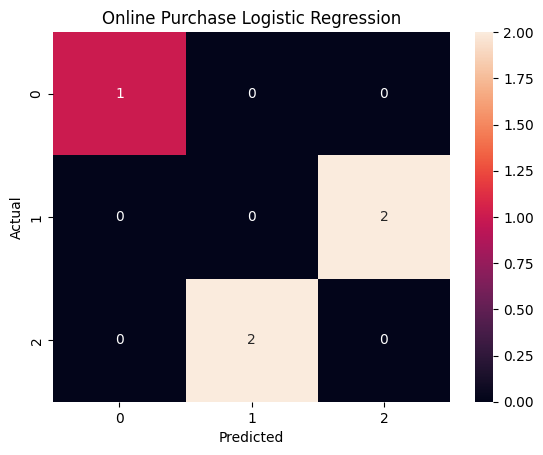

In [56]:
# ---- Confusion Matrix Heatmap ----
cm3 = pd.crosstab(y3_test, y3_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(cm3, annot=True, fmt='d').set(title='Online Purchase Logistic Regression')
plt.show()

In [57]:
new_visitor = pd.DataFrame({'age': [30], 'gender': [1], 'time_on_site': [35]})  # gender: 1=male, 0=female
new_visitor_scaled = sc.transform(new_visitor)

pred_class = model3.predict(new_visitor_scaled)[0]
probs = model3.predict_proba(new_visitor_scaled)[0]
labels = {0: "Don't buy anything", 1: 'Buy later', 2: 'Buy now'}

print('Predicted purchasing behaviour:', labels[pred_class])
for cls, p in zip(model3.classes_, probs):
    print(f'  {labels[cls]}: {p*100:.2f}%')

Predicted purchasing behaviour: Buy now
  Don't buy anything: 8.43%
  Buy later: 26.24%
  Buy now: 65.33%
